# Sección 6. Topología y fragmentación

Las métricas se calculan sobre la red bipartita y sus dos proyecciones completas. El grado cuenta vecinos distintos y no suma los pesos.

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

import eda
import red

FIGURAS = REPO / "outputs" / "figuras"
TABLAS = REPO / "outputs" / "tablas"
FIGURAS.mkdir(parents=True, exist_ok=True)
TABLAS.mkdir(parents=True, exist_ok=True)

videos, comments = eda.cargar_procesados()
B = red.build_bipartita(comments)
A = red.proj_autores(B)
V = red.proj_videos(B)
redes = {"bipartita": B, "autor-autor": A, "video-video": V}

## 6.1. Tamaño, densidad, grados y componentes

In [2]:
def metricas_topologia(nombre, graph):
    grados = np.array([degree for _, degree in graph.degree()])
    componentes = sorted(nx.connected_components(graph), key=len, reverse=True)
    mayor = graph.subgraph(componentes[0])
    return {
        "red": nombre,
        "nodos": graph.number_of_nodes(),
        "aristas": graph.number_of_edges(),
        "densidad": nx.density(graph),
        "grado_medio": grados.mean(),
        "grado_mediano": np.median(grados),
        "grado_maximo": grados.max(),
        "componentes": len(componentes),
        "tamano_componente_mayor": len(componentes[0]),
        "porcentaje_componente_mayor": 100 * len(componentes[0]) / graph.number_of_nodes(),
        "aislados": nx.number_of_isolates(graph),
        "cohesion_global": nx.node_connectivity(graph),
        "cohesion_componente_mayor": nx.node_connectivity(mayor),
        "transitividad": nx.transitivity(graph),
    }

topologia = pd.DataFrame([
    metricas_topologia(nombre, graph) for nombre, graph in redes.items()
])
topologia.to_csv(TABLAS / "topologia.csv", index=False)
display(topologia.round(4))

,red,nodos,aristas,densidad,grado_medio,grado_mediano,grado_maximo,componentes,tamano_componente_mayor,porcentaje_componente_mayor,aislados,cohesion_global,cohesion_componente_mayor,transitividad
0,bipartita,351,343,0.0056,1.9544,1.0,128,10,286,81.4815,0,0,1,0.0000
1,autor-autor,332,10732,0.1953,64.6506,48.0,183,10,276,83.1325,4,0,1,0.9840
2,video-video,19,11,0.0643,1.1579,1.0,4,10,10,52.6316,9,0,1,0.3158


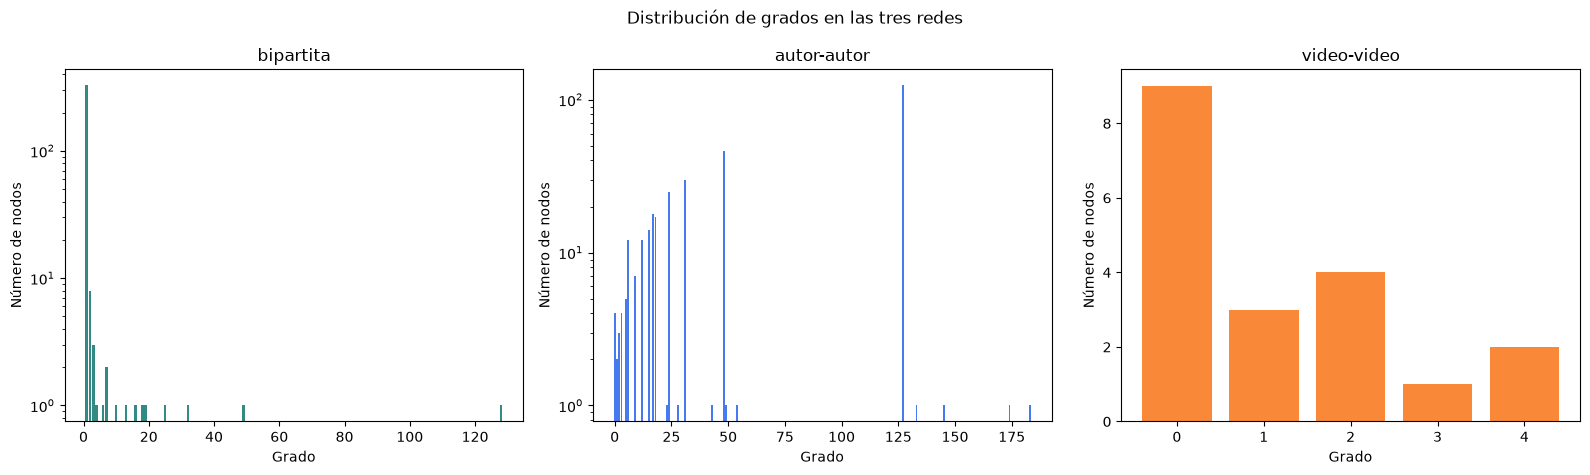

**bipartita.** El grado mediano es **1** y el máximo es **128**. La diferencia entre ambos indica que las conexiones se concentran en una parte de los nodos.

**autor-autor.** El grado mediano es **48** y el máximo es **183**. La diferencia entre ambos indica que las conexiones se concentran en una parte de los nodos.

**video-video.** El grado mediano es **1** y el máximo es **4**. La diferencia entre ambos indica que las conexiones se concentran en una parte de los nodos.

In [3]:
grados = pd.concat(
    [
        pd.DataFrame({
            "red": nombre,
            "nodo": list(dict(graph.degree()).keys()),
            "grado": list(dict(graph.degree()).values()),
        })
        for nombre, graph in redes.items()
    ],
    ignore_index=True,
)
grados.to_csv(TABLAS / "topologia_grados.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
colores = ["#0f766e", "#2563eb", "#f97316"]
for ax, (nombre, graph), color in zip(axes, redes.items(), colores):
    frecuencia = pd.Series(dict(graph.degree()).values()).value_counts().sort_index()
    ax.bar(frecuencia.index, frecuencia.values, color=color, alpha=0.85)
    ax.set_title(nombre)
    ax.set_xlabel("Grado")
    ax.set_ylabel("Número de nodos")
    if frecuencia.index.max() > 20:
        ax.set_yscale("log")
fig.suptitle("Distribución de grados en las tres redes")
fig.tight_layout()
fig.savefig(FIGURAS / "06_distribucion_grados.png", dpi=180, bbox_inches="tight")
plt.show()

for fila in topologia.itertuples():
    display(Markdown(
        f"**{fila.red}.** El grado mediano es **{fila.grado_mediano:.0f}** y el máximo "
        f"es **{fila.grado_maximo:.0f}**. La diferencia entre ambos indica que las "
        "conexiones se concentran en una parte de los nodos."
    ))

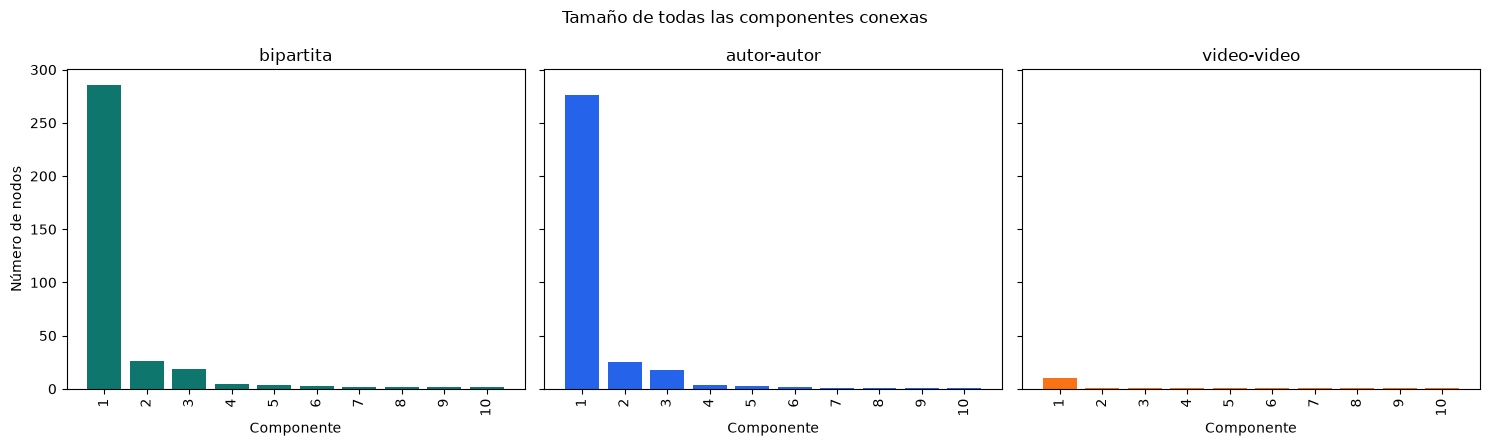

**bipartita.** Tiene **10 componentes**. La mayor contiene **286 nodos**, el **81.5 %** de la red. Se observaron **0 aislados**.

**autor-autor.** Tiene **10 componentes**. La mayor contiene **276 nodos**, el **83.1 %** de la red. Se observaron **4 aislados**.

**video-video.** Tiene **10 componentes**. La mayor contiene **10 nodos**, el **52.6 %** de la red. Se observaron **9 aislados**.

In [4]:
filas_componentes = []
for nombre, graph in redes.items():
    for numero, componente in enumerate(
        sorted(nx.connected_components(graph), key=len, reverse=True), start=1
    ):
        filas_componentes.append({
            "red": nombre,
            "componente": numero,
            "tamano": len(componente),
        })

componentes = pd.DataFrame(filas_componentes)
componentes.to_csv(TABLAS / "topologia_componentes.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, nombre, color in zip(axes, redes, colores):
    subset = componentes[componentes["red"] == nombre]
    ax.bar(subset["componente"].astype(str), subset["tamano"], color=color)
    ax.set_title(nombre)
    ax.set_xlabel("Componente")
    ax.tick_params(axis="x", labelrotation=90)
axes[0].set_ylabel("Número de nodos")
fig.suptitle("Tamaño de todas las componentes conexas")
fig.tight_layout()
fig.savefig(FIGURAS / "06_componentes.png", dpi=180, bbox_inches="tight")
plt.show()

for fila in topologia.itertuples():
    display(Markdown(
        f"**{fila.red}.** Tiene **{fila.componentes} componentes**. La mayor contiene "
        f"**{fila.tamano_componente_mayor} nodos**, el "
        f"**{fila.porcentaje_componente_mayor:.1f} %** de la red. "
        f"Se observaron **{fila.aislados} aislados**."
    ))

## 6.2. Cohesión y transitividad

In [5]:
for fila in topologia.itertuples():
    display(Markdown(
        f"**{fila.red}.** La conectividad de nodos global es **{fila.cohesion_global}** "
        f"y en su componente mayor es **{fila.cohesion_componente_mayor}**. "
        f"La transitividad es **{fila.transitividad:.3f}**."
    ))

display(Markdown(
    f"Las tres redes tienen cohesión global **0** porque son desconectadas. "
    f"En cada componente mayor, la conectividad es **1**: existe al menos un nodo cuya "
    "eliminación puede separar esa componente. La transitividad bipartita es "
    f"**{topologia.loc[topologia['red'] == 'bipartita', 'transitividad'].iloc[0]:.0f}** "
    "porque un grafo bipartito no contiene triángulos. La transitividad autor-autor de "
    f"**{topologia.loc[topologia['red'] == 'autor-autor', 'transitividad'].iloc[0]:.3f}** "
    "se debe en gran parte a que todos los autores de un mismo video forman una camarilla "
    "al proyectar la red. No debe interpretarse como amistad o conversación."
))

**bipartita.** La conectividad de nodos global es **0** y en su componente mayor es **1**. La transitividad es **0.000**.

**autor-autor.** La conectividad de nodos global es **0** y en su componente mayor es **1**. La transitividad es **0.984**.

**video-video.** La conectividad de nodos global es **0** y en su componente mayor es **1**. La transitividad es **0.316**.

Las tres redes tienen cohesión global **0** porque son desconectadas. En cada componente mayor, la conectividad es **1**: existe al menos un nodo cuya eliminación puede separar esa componente. La transitividad bipartita es **0** porque un grafo bipartito no contiene triángulos. La transitividad autor-autor de **0.984** se debe en gran parte a que todos los autores de un mismo video forman una camarilla al proyectar la red. No debe interpretarse como amistad o conversación.

## 6.3. Nodos periféricos y aislados

In [6]:
filas_perifericos = []
for nombre, graph in redes.items():
    for node, degree in graph.degree():
        if degree <= 1:
            filas_perifericos.append({
                "red": nombre,
                "nodo": node,
                "tipo": graph.nodes[node].get("tipo", nombre.split("-")[0]),
                "grado": degree,
                "aislado": degree == 0,
            })

perifericos = pd.DataFrame(filas_perifericos)
perifericos.to_csv(TABLAS / "topologia_perifericos.csv", index=False)
resumen_perifericos = (
    perifericos.groupby(["red", "tipo", "grado"])
    .size()
    .rename("nodos")
    .reset_index()
)
display(resumen_perifericos)

videos_aislados = perifericos[
    (perifericos["red"] == "video-video") & perifericos["aislado"]
].merge(videos[["video_id", "title", "channel_name"]], left_on="nodo", right_on="video_id")
display(videos_aislados[["nodo", "title", "channel_name", "grado"]])

display(Markdown(
    f"En la proyección video-video, **{len(videos_aislados)} videos** no comparten autores "
    "con otro video de la muestra. En la red bipartita no hay aislados, porque cada nodo "
    "se crea a partir de un comentario observado. Los nodos de grado uno son periféricos "
    "dentro de esta muestra, pero los datos no permiten afirmar que esas cuentas o videos "
    "carezcan de otras conexiones fuera de lo recolectado."
))

,red,tipo,grado,nodos
0,autor-autor,autor,0,4
1,autor-autor,autor,1,2
2,bipartita,autor,1,323
3,bipartita,video,1,4
4,video-video,video,0,9
5,video-video,video,1,3


,nodo,title,channel_name,grado
0,3Nfp9h5avBI,"Noticiero en Directo 1 pm, 28 de Agosto de 2026",Noticiero Guatevisión 13 Hrs.,0
1,JkpVO1hx2f8,10 Preguntas a un año del Paro Nacional,Quorum,0
2,OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemal...,Noticias Telemundo,0
3,TT4qJ5FXHYE,I’x K’at: el primer equipo guatemalteco de pel...,Quorum,0
4,UhL9y3KUl8E,SHAI WA: la vecina queer de Casa Presidencial,Quorum,0
5,X_FAIef8qlE,Cruzando la ciudad a puro Transmetro,Quorum,0
6,lj983NWyAQY,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,0
7,s0eco-BofOs,¿Quiénes pagan más en Centroamérica?,Quorum,0
8,zweosulrwA8,Edén por Salud: empleo inclusivo para personas...,Quorum,0


En la proyección video-video, **9 videos** no comparten autores con otro video de la muestra. En la red bipartita no hay aislados, porque cada nodo se crea a partir de un comentario observado. Los nodos de grado uno son periféricos dentro de esta muestra, pero los datos no permiten afirmar que esas cuentas o videos carezcan de otras conexiones fuera de lo recolectado.

## 6.4. Hallazgos estructurales

In [7]:
b = topologia.set_index("red").loc["bipartita"]
a = topologia.set_index("red").loc["autor-autor"]
v = topologia.set_index("red").loc["video-video"]

display(Markdown(
    f"La red bipartita se divide en **{int(b['componentes'])} componentes**, aunque su "
    f"componente mayor concentra **{b['porcentaje_componente_mayor']:.1f} %** de los nodos. "
    f"La proyección video-video conserva **{int(v['componentes'])} componentes** y deja "
    f"**{int(v['aislados'])} de {int(v['nodos'])} videos aislados**. Estos resultados coinciden "
    "con la escasa participación cruzada observada: la mayoría de las cuentas aparece en "
    "un solo video de los incluidos."
))
display(Markdown(
    f"La densidad autor-autor es **{a['densidad']:.3f}**, mucho mayor que la densidad "
    f"video-video de **{v['densidad']:.3f}**. Esta diferencia surge del mecanismo de "
    "proyección. Un video con muchos autores genera muchas parejas autor-autor, aunque esos "
    "autores no hayan interactuado entre sí. La fragmentación describe la cobertura de esta "
    "muestra y no la totalidad de la actividad de las cuentas en YouTube."
))

La red bipartita se divide en **10 componentes**, aunque su componente mayor concentra **81.5 %** de los nodos. La proyección video-video conserva **10 componentes** y deja **9 de 19 videos aislados**. Estos resultados coinciden con la escasa participación cruzada observada: la mayoría de las cuentas aparece en un solo video de los incluidos.

La densidad autor-autor es **0.195**, mucho mayor que la densidad video-video de **0.064**. Esta diferencia surge del mecanismo de proyección. Un video con muchos autores genera muchas parejas autor-autor, aunque esos autores no hayan interactuado entre sí. La fragmentación describe la cobertura de esta muestra y no la totalidad de la actividad de las cuentas en YouTube.